# 01 — Preparación de datos (`01_data.do` → Python)

Este notebook traduce el do-file `104.04_LatamDiD_01_data.do` de Stata realizado por Tobias Grohmann

**¿Qué hace?**  
Ensambla el dataset panel `did_latam_data` que usarán los notebooks de visualización y análisis.
Combina tres fuentes de datos y codifica manualmente cada Régimen de Libre Movimiento (FMR) 
como variables dummy para cada corredor país-a-país y año.

**Fuentes de datos:**
1. `UN_matrix.dta` — matriz base de todos los corredores país×año
2. `GTMD2_301_trips.dta` — flujos de visitantes (movilidad no migratoria)
3. `GaskinAbel2025.dta` — flujos y stocks de migración (Gaskin & Abel, 2025)
4. `UN_codes.dta` — códigos de región de Naciones Unidas

> **Nota:** Las fuentes originales son archivos `.dta` de Stata del proyecto de Tobias.  
> El dataset final (`did_latam_data.csv`) es el punto de entrada para los notebooks 2 y 3.


In [32]:
import pandas as pd
import numpy as np



## 1. Cargar y combinar los datos de movilidad

Se crea una matriz de corredores posibles. Creo los corredores solo para Suramérica


In [ ]:
sa_countries = [
    "ARG", "BOL", "BRA", "CHL", "COL", "ECU",
    "PRY", "PER", "URY", "VEN",
    "GUY", "SUR", "GUF"   # ← agregar: controles no-tratados (nunca en ningún FMR)
]

In [34]:
# --- Cargar GTMD2 y construir df base: corredores SA × años ---
vis = pd.read_csv(r"c:/Data/GTMD2/GTMD2_Data_MIGMOBS_share.csv", low_memory=False)

df = (
    vis[
        vis["iso3code_i"].isin(sa_countries) &
        vis["iso3code_j"].isin(sa_countries) &
        (vis["code_i"] != vis["code_j"])
    ]
    [["code_i", "code_j", "iso3code_i", "iso3code_j", "year",
      "gtmd2_vflow_int", "abel_migflow","riks_stock"]]
    .rename(columns={"gtmd2_vflow_int": "vflow", "abel_migflow": "mflow","riks_stock":"mstock"})
    .copy()
)

df["iso3code_ij"]     = df["iso3code_i"] + "_" + df["iso3code_j"]
df["un_region_inter_i"] = 5  # todos son Sudamérica
df["un_region_inter_j"] = 5

print(f"Corredores únicos: {df[['iso3code_i','iso3code_j']].drop_duplicates().shape[0]}")
print(f"Años: {df['year'].min()} - {df['year'].max()}")
print(f"Observaciones: {len(df):,}")


Corredores únicos: 90
Años: 1995 - 2022
Observaciones: 2,520


## 2. Codificación de los FMRs

Cada FMR se codifica como una variable dummy (0/1) **desde la perspectiva del país de destino `j`**:  
`valor = 1` si el país `j` aplica el FMR a los nacionales del país `i`.

La fuente es Acosta & van der Baaren (2024), *Free Movement Regimes Dataset*.

---
### Convención importante

Los FMRs no son necesariamente simétricos. Por ejemplo:  
- Chile aplica el MERCOSUR2 a los nacionales de ARG/BRA/PRY/URY/BOL, pero **no** a los de COL, ECU, PER.  
- Colombia dejó de aplicar el MERCOSUR2 a Venezuela en 2014 y a Chile en 2019.

Por eso, la codificación se hace corredor por corredor.


### MERCOSUR 1 — Miembros fundadores

**Países:** Argentina, Brasil, Paraguay, Uruguay  
**Vigencia:** desde 2009  
**Instrumento:** Acuerdo sobre Residencia para Nacionales de los Estados Partes del MERCOSUR (2002), en vigor desde 2009.

Otorga residencia temporal (2 años) y permanente a nacionales de cualquier país miembro que deseen residir en otro. El acuerdo es **simétrico**: cada país aplica el FMR a los demás tres miembros.

> **Variable:** `mercosur1 = 1` para todo par (i, j) donde ambos son miembros y `year >= 2009`.

In [35]:
# ── MERCOSUR1: los 4 países fundadores ──────────────────────────────────────
# Argentina, Brasil, Paraguay y Uruguay desde 2009
# Cada país aplica el FMR a los demás miembros

members_m1 = ["ARG", "BRA", "PRY", "URY"]
df["mercosur1"] = 0

for country_j in members_m1:
    cond = (
        (df["iso3code_j"] == country_j) &
        (df["iso3code_i"].isin(members_m1)) &
        (df["year"] >= 2009)
    )
    df.loc[cond, "mercosur1"] = 1


### MERCOSUR 2 — Estados asociados

**Países adherentes:** Bolivia (2009), Chile (2009), Perú (2011), Colombia (2012), Ecuador (2014)  
**Instrumento:** Extensión del Acuerdo de Residencia del MERCOSUR a los Estados Asociados.

Las fechas indican la entrada en vigor, no la firma. El acuerdo es **asimétrico en algunas combinaciones**:

| País destino (j) | Aplica a (i) | Desde |
|---|---|---|
| ARG, BRA, PRY, URY | BOL, CHL | 2009 |
| ARG, BRA, PRY, URY | PER | 2011 |
| ARG, BRA, PRY, URY | COL | 2012 |
| ARG, BRA, PRY, URY | ECU | 2014 |
| CHL | miembros M1 + BOL | 2009 (no aplica a PER, COL, ECU) |
| BOL | miembros M1 + todos los adherentes | fechas respectivas |
| PER | todos | desde 2011 en adelante |
| COL | todos excepto CHL post-2019 | desde 2012 |
| ECU | todos | 2014 |

> **Variable:** `mercosur2 = 1` según las reglas anteriores. Colombia dejó de aplicar el acuerdo a Chile en 2019.

In [36]:
# ── MERCOSUR2: países adherentes (no miembros plenos) ───────────────────────
# BOL, CHL adhieren en 2009; PER en 2011; COL en 2012; ECU en 2014
# Las fechas son de entrada en vigor, no de firma
# Importante: no todas las combinaciones son simétricas

df["mercosur2"] = 0

# ARG, BRA, PRY, URY aplican a todos los adherentes según sus fechas de adhesión
for country_j in ["ARG", "BRA", "PRY", "URY"]:
    rules = {
        "BOL": 2009, "CHL": 2009, "PER": 2011, "COL": 2012, "ECU": 2014
    }
    for country_i, year_start in rules.items():
        df.loc[
            (df["iso3code_j"] == country_j) &
            (df["iso3code_i"] == country_i) &
            (df["year"] >= year_start),
            "mercosur2"
        ] = 1

# Chile: aplica a los 4 miembros y a BOL, pero NO a PER, COL, ECU
df.loc[(df["iso3code_j"] == "CHL") & (df["iso3code_i"].isin(members_m1)) & (df["year"] >= 2009), "mercosur2"] = 1
df.loc[(df["iso3code_j"] == "CHL") & (df["iso3code_i"] == "BOL") & (df["year"] >= 2009), "mercosur2"] = 1

# Bolivia: aplica a todos (miembros + adherentes según fechas)
df.loc[(df["iso3code_j"] == "BOL") & (df["iso3code_i"].isin(members_m1)) & (df["year"] >= 2009), "mercosur2"] = 1
df.loc[(df["iso3code_j"] == "BOL") & (df["iso3code_i"] == "CHL") & (df["year"] >= 2009), "mercosur2"] = 1
df.loc[(df["iso3code_j"] == "BOL") & (df["iso3code_i"] == "PER") & (df["year"] >= 2011), "mercosur2"] = 1
df.loc[(df["iso3code_j"] == "BOL") & (df["iso3code_i"] == "COL") & (df["year"] >= 2012), "mercosur2"] = 1
df.loc[(df["iso3code_j"] == "BOL") & (df["iso3code_i"] == "ECU") & (df["year"] >= 2014), "mercosur2"] = 1

# Perú: adhiere en 2011, aplica a miembros + otros adherentes desde sus propias fechas
rules_per = {**{c: 2011 for c in members_m1}, "BOL": 2011, "CHL": 2011, "COL": 2012, "ECU": 2014}
for country_i, year_start in rules_per.items():
    df.loc[
        (df["iso3code_j"] == "PER") & (df["iso3code_i"] == country_i) & (df["year"] >= year_start),
        "mercosur2"
    ] = 1

# Colombia: adhiere en 2012; deja de aplicar a CHL en 2019 y a VEN en 2014
rules_col = {**{c: 2012 for c in members_m1}, "BOL": 2012, "PER": 2012, "ECU": 2014}
for country_i, year_start in rules_col.items():
    df.loc[
        (df["iso3code_j"] == "COL") & (df["iso3code_i"] == country_i) & (df["year"] >= year_start),
        "mercosur2"
    ] = 1
# COL deja de aplicar a CHL en 2019
df.loc[(df["iso3code_j"] == "COL") & (df["iso3code_i"] == "CHL") & (df["year"] > 2019), "mercosur2"] = 0

# Ecuador: adhiere en 2014
rules_ecu = {**{c: 2014 for c in members_m1}, "BOL": 2014, "CHL": 2014, "PER": 2014, "COL": 2014}
for country_i, year_start in rules_ecu.items():
    df.loc[
        (df["iso3code_j"] == "ECU") & (df["iso3code_i"] == country_i) & (df["year"] >= year_start),
        "mercosur2"
    ] = 1


In [37]:
# ── Argentina FMRs (bilaterales previos al MERCOSUR) ────────────────────────
# Estos acuerdos PRECEDEN al MERCOSUR y son los que más tempranamente activan el tratamiento

df["argfmrs"] = 0

# ARG-BOL: 1999-2016 (primer convenio 1998, en vigor desde 1999, discontinuado en 2016)
for j, i in [("ARG", "BOL"), ("BOL", "ARG")]:
    df.loc[(df["iso3code_j"] == j) & (df["iso3code_i"] == i) &
           (df["year"] >= 1999) & (df["year"] <= 2016), "argfmrs"] = 1

# ARG-PER: desde 2000 (en vigor continuo hasta hoy)
for j, i in [("ARG", "PER"), ("PER", "ARG")]:
    df.loc[(df["iso3code_j"] == j) & (df["iso3code_i"] == i) & (df["year"] >= 2000), "argfmrs"] = 1

# ARG-BRA y ARG-URY: desde 2006 (anticipan el MERCOSUR)
for j, i in [("ARG", "BRA"), ("BRA", "ARG"), ("ARG", "URY"), ("URY", "ARG")]:
    df.loc[(df["iso3code_j"] == j) & (df["iso3code_i"] == i) & (df["year"] >= 2006), "argfmrs"] = 1

# ARG-PRY: NUNCA entró en vigor (firmado pero no ratificado)


### FMRs bilaterales de Argentina (pre-MERCOSUR)

Acuerdos bilaterales firmados por Argentina **antes** de la entrada en vigor del MERCOSUR ampliado. Son relevantes porque activan el tratamiento más tempranamente en ciertos corredores.

| Corredor | Vigencia | Notas |
|---|---|---|
| ARG ↔ BOL | 1999–2016 | Convenio de 1998; discontinuado en 2016 |
| ARG ↔ PER | desde 2000 | En vigor continuo |
| ARG ↔ BRA | desde 2006 | Anticipa el MERCOSUR ampliado |
| ARG ↔ URY | desde 2006 | Anticipa el MERCOSUR ampliado |
| ARG ↔ PRY | — | Firmado pero **nunca ratificado** |

> **Variable:** `argfmrs = 1` para los corredores activos según las fechas. Todos son simétricos (aplica en ambas direcciones).

In [38]:
# ── Ecuador - Venezuela ──────────────────────────────────────────────────────
# En vigor desde 2011; Ecuador dejó de implementarlo desde 2020; denunciado en 2025
# Nota: el corredor VEN→ECU se mantiene hasta 2025 (desde la perspectiva venezolana),
# pero el corredor ECU→VEN termina en 2020

df["ecuven"] = 0
df.loc[(df["iso3code_j"] == "ECU") & (df["iso3code_i"] == "VEN") &
       (df["year"] >= 2011) & (df["year"] <= 2020), "ecuven"] = 1
df.loc[(df["iso3code_j"] == "VEN") & (df["iso3code_i"] == "ECU") &
       (df["year"] >= 2011), "ecuven"] = 1

# ── Brasil - Uruguay ─────────────────────────────────────────────────────────
# Acuerdo de residencia permanente que va más allá del MERCOSUR, desde 2017
# (nota: el do-file dice desde 2017, aunque el acuerdo fue firmado en 2013)

df["braury"] = 0
df.loc[(df["iso3code_j"] == "BRA") & (df["iso3code_i"] == "URY") & (df["year"] >= 2017), "braury"] = 1
df.loc[(df["iso3code_j"] == "URY") & (df["iso3code_i"] == "BRA") & (df["year"] >= 2017), "braury"] = 1


### Acuerdos bilaterales adicionales

#### Ecuador – Venezuela (`ecuven`)
**Vigencia:** 2011–presente (con restricciones desde 2020)  
Ecuador otorgó libre movimiento a ciudadanos venezolanos desde 2011, pero suspendió su implementación en 2020 (aunque el acuerdo no fue formalmente denunciado hasta 2025). Desde la perspectiva venezolana, el corredor VEN→ECU sigue activo.

> **Asimétrico:** `ECU→VEN`: 2011–2020 / `VEN→ECU`: desde 2011

#### Brasil – Uruguay (`braury`)
**Vigencia:** desde 2017  
Acuerdo de residencia permanente que va más allá del MERCOSUR, otorgando derechos más amplios a nacionales de ambos países. Firmado en 2013, en vigor desde 2017.

> **Simétrico:** `BRA↔URY`: desde 2017

In [39]:
# ── CAN1: Comunidad Andina, versión no comprehensiva (2003-2020) ─────────────
# Decisión 545: solo cubría trabajadores transfronterizos, de temporada e intra-corporativos
# Miembros: BOL, COL, ECU, PER

core_can = ["BOL", "COL", "ECU", "PER"]
df["can1"] = 0
for country_j in core_can:
    df.loc[
        (df["iso3code_j"] == country_j) &
        (df["iso3code_i"].isin(core_can)) &
        (df["year"] >= 2003) & (df["year"] <= 2020),
        "can1"
    ] = 1

# ── CAN2: Comunidad Andina, versión comprehensiva (2021 en adelante) ─────────
# Decisión 878: cubre a todos los ciudadanos, residencia temporal y permanente
# Reemplaza a CAN1

df["can2"] = 0
for country_j in core_can:
    df.loc[
        (df["iso3code_j"] == country_j) &
        (df["iso3code_i"].isin(core_can)) &
        (df["year"] >= 2021),
        "can2"
    ] = 1


### Comunidad Andina (CAN)

**Países miembros:** Bolivia, Colombia, Ecuador, Perú

El régimen andino se codifica en dos versiones que reflejan cambios cualitativos en su alcance:

#### CAN 1 — Decisión 545 (`can1`)
**Vigencia:** 2003–2020  
Instrumento limitado: cubría únicamente trabajadores transfronterizos, de temporada e intra-corporativos. No constituía libre movimiento pleno para todos los ciudadanos.

#### CAN 2 — Decisión 878 (`can2`)
**Vigencia:** desde 2021  
Reemplaza a CAN1 con un acuerdo comprehensivo que cubre a todos los ciudadanos, incluyendo residencia temporal y permanente. Representa un salto cualitativo en el alcance del FMR.

> Ambas versiones son **simétricas** entre los cuatro miembros.

In [40]:
# ── Variables de tratamiento por escenario ───────────────────────────────────
#
# FMR_all          todos los regímenes (MERCOSUR + bilaterales ARG + ECU-VEN + BRA-URY + CAN)
# FMR_Mercosur     solo MERCOSUR (miembros fundadores + estados asociados)
# FMR_Mercosur_CAN MERCOSUR + CAN2 (Decisión 878, versión comprehensiva desde 2021)

cols_all      = ["mercosur1", "mercosur2", "argfmrs", "ecuven", "braury", "can1", "can2"]
cols_mercosur = ["mercosur1", "mercosur2"]
cols_mer_can  = ["mercosur1", "mercosur2", "can2"]

df["FMR_all"]          = (df[cols_all].sum(axis=1)      > 0).astype(int)
df["FMR_Mercosur"]     = (df[cols_mercosur].sum(axis=1) > 0).astype(int)
df["FMR_Mercosur_CAN"] = (df[cols_mer_can].sum(axis=1)  > 0).astype(int)

print("Distribución de escenarios FMR:")
print(pd.DataFrame({
    "FMR_all":          df["FMR_all"].value_counts(),
    "FMR_Mercosur":     df["FMR_Mercosur"].value_counts(),
    "FMR_Mercosur_CAN": df["FMR_Mercosur_CAN"].value_counts(),
}).sort_index())
print(f"\nCorredores-año activos:")
print(f"  FMR_all:          {df['FMR_all'].sum():,}")
print(f"  FMR_Mercosur:     {df['FMR_Mercosur'].sum():,}")
print(f"  FMR_Mercosur_CAN: {df['FMR_Mercosur_CAN'].sum():,}")


Distribución de escenarios FMR:
   FMR_all  FMR_Mercosur  FMR_Mercosur_CAN
0     1507          1701              1701
1     1013           819               819

Corredores-año activos:
  FMR_all:          1,013
  FMR_Mercosur:     819
  FMR_Mercosur_CAN: 819


### Variables de tratamiento — Escenarios FMR

Se construyen tres variables dummy de tratamiento según qué regímenes se consideran activos:

| Variable | Regímenes incluidos | Lógica |
|---|---|---|
| `FMR_all` | mercosur1, mercosur2, argfmrs, ecuven, braury, can1, can2 | Cualquier FMR activo |
| `FMR_Mercosur` | mercosur1, mercosur2 | Solo bloque MERCOSUR |
| `FMR_Mercosur_CAN` | mercosur1, mercosur2, can2 | MERCOSUR + CAN comprehensivo (Decisión 878, desde 2021) |

`FMR_Mercosur_CAN` excluye CAN1 deliberadamente: la Decisión 545 (2003–2020) cubría solo trabajadores específicos y no equivale a libre movimiento pleno. Solo se incorpora CAN2 (Decisión 878), que sí es un acuerdo comprehensivo comparable al MERCOSUR.

## 3. Filtros finales y guardado

Se mantienen solo corredores internacionales (i ≠ j) de América del Sur 
(región intermedia ONU = 5), excluyendo Malvinas (FLK).


In [41]:
# Eliminar observaciones sin dato de migración
df = df[df["mflow"].notna()].copy()

# Identificador numérico único de corredor
df["code_ij"] = df.groupby(["code_i", "code_j"]).ngroup() + 1

print(f"Observaciones finales: {len(df):,}")
print(f"Corredores únicos: {df['code_ij'].nunique()}")
print(f"Años: {df['year'].min()} - {df['year'].max()}")


Observaciones finales: 2,250
Corredores únicos: 90
Años: 1995 - 2019


In [42]:
# Guardar como CSV (equivale a: save did_latam_data.dta + export delimited)
df.to_csv("Output/did_latam_data.csv", index=False)
print("Guardado: did_latam_data.csv")


df.head()


Guardado: did_latam_data.csv


,code_i,code_j,iso3code_i,iso3code_j,year,vflow,mflow,mstock,iso3code_ij,un_region_inter_i,...,mercosur2,argfmrs,ecuven,braury,can1,can2,FMR_all,FMR_Mercosur,FMR_Mercosur_CAN,code_ij
58364,32,68,ARG,BOL,1995,523292.53,4548.2285,25141.0,ARG_BOL,5,...,0,0,0,0,0,0,0,0,0,1
58365,32,68,ARG,BOL,1996,587587.50,4605.7813,25707.0,ARG_BOL,5,...,0,0,0,0,0,0,0,0,0,1
58366,32,68,ARG,BOL,1997,699757.69,4662.0659,26253.0,ARG_BOL,5,...,0,0,0,0,0,0,0,0,0,1
58367,32,68,ARG,BOL,1998,727586.31,4717.1934,26813.0,ARG_BOL,5,...,0,0,0,0,0,0,0,0,0,1
58368,32,68,ARG,BOL,1999,667494.31,4771.8999,27419.0,ARG_BOL,5,...,0,1,0,0,0,0,1,0,0,1


In [43]:
import os
OUTDIR = "Output/"
os.makedirs(OUTDIR, exist_ok=True)

---
## Visualizaciones

Sección de visualización basada en el do-file `104.04_LatamDiD_02_dataviz.do` de Tobias Grohmann.


In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Paleta de colores (idéntica al Stata: RGB normalizado a [0,1])
COLORS = {
    "no_fmr":    tuple(x/255 for x in (153, 153, 153)),  # gris
    "argfmrs":   tuple(x/255 for x in (86,  180, 233)),  # azul claro
    "can1":      tuple(x/255 for x in (240, 228, 66)),   # amarillo
    "mercosur1": tuple(x/255 for x in (0,   114, 178)),  # azul
    "mercosur2": tuple(x/255 for x in (0,   70,  110)),  # azul oscuro
    "ecuven":    tuple(x/255 for x in (213, 94,  0)),    # naranja
    "can1_m1":   tuple(x/255 for x in (120, 171, 122)),  # verde (CAN1+MER1)
    "can1_m2":   tuple(x/255 for x in (120, 149, 88)),   # verde oscuro (CAN1+MER2)
    "can2_m1":   tuple(x/255 for x in (128, 134, 89)),   # oliva (CAN2+MER1)
    "can2_m2":   tuple(x/255 for x in (128, 112, 55)),   # marrón (CAN2+MER2)
    "braury":    tuple(x/255 for x in (204, 121, 167)),  # rosa/violeta
}

# Etiqueta de corredor (usada en ambas figuras)
df["corridor_label"] = df["iso3code_i"] + "\u2192" + df["iso3code_j"]

## Figura 1 — Gantt de tratamiento agrupado por país destino

Cada fila es un corredor origen→destino. Los corredores están **agrupados por país de destino** (etiqueta a la izquierda), con fondo alternado por grupo. El color indica qué FMR está activo ese año para ese corredor.

Un solo panel sin dividir facilita comparar cuándo y qué regímenes activó cada destino.

In [45]:
def get_fmr_color(row):
    """Determina el color de un corredor-año según qué FMR está activo.
    Prioriza overlaps sobre regímenes individuales."""
    if row["can2"] == 1 and row["mercosur2"] == 1: return COLORS["can2_m2"]
    if row["can2"] == 1 and row["mercosur1"] == 1: return COLORS["can2_m1"]
    if row["can1"] == 1 and row["mercosur2"] == 1: return COLORS["can1_m2"]
    if row["can1"] == 1 and row["mercosur1"] == 1: return COLORS["can1_m1"]
    if row["braury"]    == 1: return COLORS["braury"]
    if row["ecuven"]    == 1: return COLORS["ecuven"]
    if row["mercosur2"] == 1: return COLORS["mercosur2"]
    if row["mercosur1"] == 1: return COLORS["mercosur1"]
    if row["can1"]      == 1: return COLORS["can1"]
    if row["argfmrs"]   == 1: return COLORS["argfmrs"]
    return COLORS["no_fmr"]

df["color"] = df.apply(get_fmr_color, axis=1)

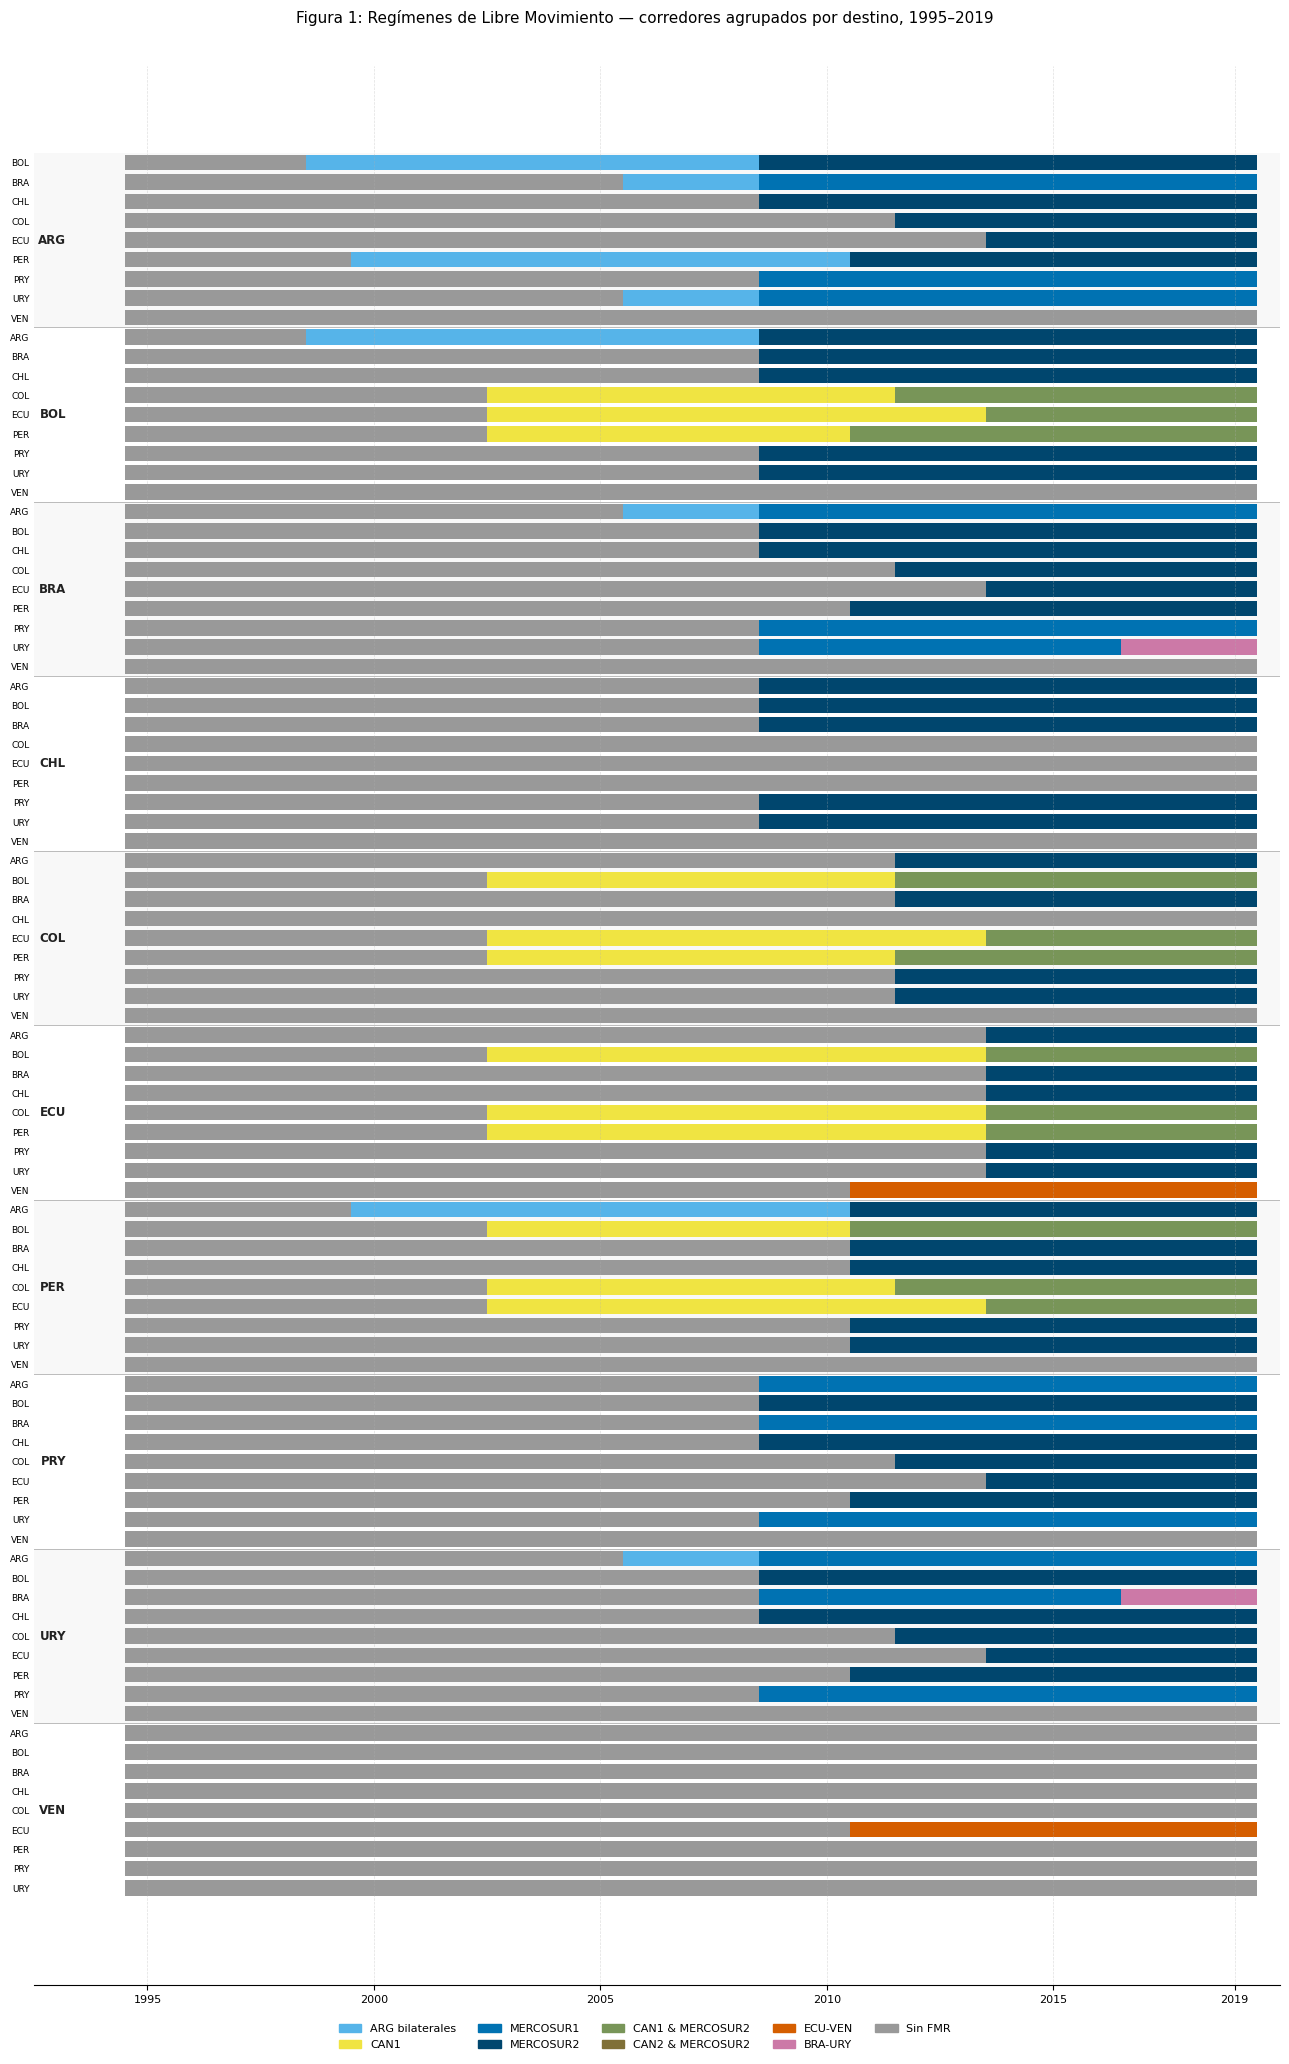

In [46]:
# ── Construir lista de corredores ordenada por destino ───────────────────────
destinations_sorted = sorted(df["iso3code_j"].unique())

ordered_pairs = []          # lista de (orig, dest)
dest_group_info = {}        # dest → (start_idx, end_idx)

for dest in destinations_sorted:
    origins = sorted(df[df["iso3code_j"] == dest]["iso3code_i"].unique())
    start = len(ordered_pairs)
    for orig in origins:
        ordered_pairs.append((orig, dest))
    dest_group_info[dest] = (start, len(ordered_pairs))

n = len(ordered_pairs)

# Merge para asignar y_gantt eficientemente
pair_df = pd.DataFrame(ordered_pairs, columns=["iso3code_i", "iso3code_j"])
pair_df["y_gantt"] = range(n)
df_g = df.merge(pair_df, on=["iso3code_i", "iso3code_j"], how="left")

# ── Figura ───────────────────────────────────────────────────────────────────
fig_h = max(12, n * 0.2 + 2)
fig, ax = plt.subplots(figsize=(13, fig_h))

# Barras coloreadas
ax.barh(df_g["y_gantt"], width=1, left=df_g["year"] - 0.5,
        color=df_g["color"].tolist(), linewidth=0)

# Fondos alternados y etiquetas de grupo
bg_colors = ["#f4f4f4", "white"]
for i, dest in enumerate(destinations_sorted):
    start, end = dest_group_info[dest]
    mid = (start + end - 1) / 2

    ax.axhspan(start - 0.5, end - 0.5,
               facecolor=bg_colors[i % 2], alpha=0.6, zorder=0)

    ax.text(1993.2, mid, dest,
            fontsize=8.5, fontweight="bold", ha="right", va="center",
            color="#222222")

    if start > 0:
        ax.axhline(start - 0.5, color="#bbbbbb", linewidth=0.7, zorder=3)

# Etiquetas eje Y: solo origen
ax.set_yticks(range(n))
ax.set_yticklabels([p[0] for p in ordered_pairs], fontsize=6.5)
ax.invert_yaxis()

ax.set_xticks([1995, 2000, 2005, 2010, 2015, 2019])
ax.set_xlim(1992.5, 2020)
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.4, zorder=1)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", length=0)
ax.spines[["top", "right", "left"]].set_visible(False)

legend_items = [
    mpatches.Patch(color=COLORS["argfmrs"],   label="ARG bilaterales"),
    mpatches.Patch(color=COLORS["can1"],       label="CAN1"),
    mpatches.Patch(color=COLORS["mercosur1"],  label="MERCOSUR1"),
    mpatches.Patch(color=COLORS["mercosur2"],  label="MERCOSUR2"),
    mpatches.Patch(color=COLORS["can1_m2"],    label="CAN1 & MERCOSUR2"),
    mpatches.Patch(color=COLORS["can2_m2"],    label="CAN2 & MERCOSUR2"),
    mpatches.Patch(color=COLORS["ecuven"],     label="ECU-VEN"),
    mpatches.Patch(color=COLORS["braury"],     label="BRA-URY"),
    mpatches.Patch(color=COLORS["no_fmr"],     label="Sin FMR"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=5,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(
    "Figura 1: Reg\u00edmenes de Libre Movimiento \u2014 corredores agrupados por destino, 1995\u20132019",
    fontsize=11, y=1.005
)
plt.tight_layout()
plt.savefig(OUTDIR + "Fig01_treat_corridor_grouped.png", dpi=150, bbox_inches="tight")
plt.show()

## Figura 1b — Adopción de FMRs en el tiempo

Área apilada: cada capa es un tipo de régimen (categorías **excluyentes**, mismo orden de prioridad que la paleta de colores). El eje Y muestra cuántos corredores están bajo ese régimen en cada año.

Las líneas verticales marcan los hitos clave de activación. La línea punteada horizontal indica el total de corredores posibles.

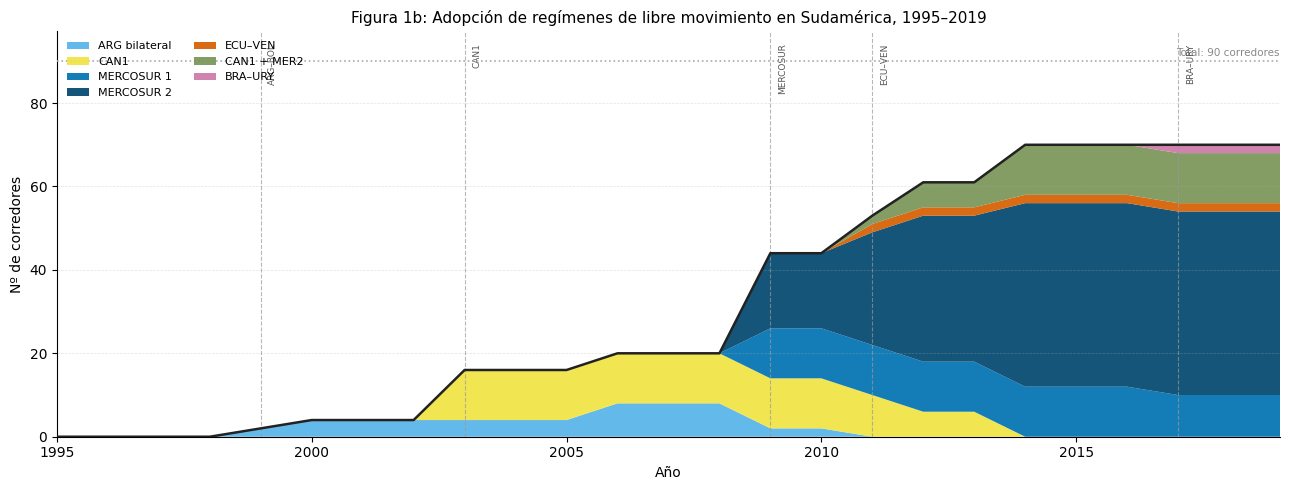

In [47]:
# ── Categoría FMR excluyente (misma prioridad que get_fmr_color) ─────────────────
def fmr_cat(row):
    if row["can1"] == 1 and row["mercosur2"] == 1: return "CAN1 + MER2"
    if row["can1"] == 1 and row["mercosur1"] == 1: return "CAN1 + MER1"
    if row["braury"]    == 1: return "BRA–URY"
    if row["ecuven"]    == 1: return "ECU–VEN"
    if row["mercosur2"] == 1: return "MERCOSUR 2"
    if row["mercosur1"] == 1: return "MERCOSUR 1"
    if row["can1"]      == 1: return "CAN1"
    if row["argfmrs"]   == 1: return "ARG bilateral"
    return "Sin FMR"

df["fmr_cat"] = df.apply(fmr_cat, axis=1)

# Pivot: corredores × año → conteo
pivot = df.groupby(["year", "fmr_cat"]).size().unstack(fill_value=0)
total_per_year = df.groupby("year").size()

# Orden de apilamiento (cronológico de aparición)
cat_order = ["ARG bilateral", "CAN1", "MERCOSUR 1", "MERCOSUR 2",
             "ECU–VEN", "CAN1 + MER1", "CAN1 + MER2", "BRA–URY"]
cat_order = [c for c in cat_order if c in pivot.columns]

stack_colors = {
    "ARG bilateral": COLORS["argfmrs"],
    "CAN1":          COLORS["can1"],
    "MERCOSUR 1":    COLORS["mercosur1"],
    "MERCOSUR 2":    COLORS["mercosur2"],
    "ECU–VEN":  COLORS["ecuven"],
    "CAN1 + MER1":   COLORS["can1_m1"],
    "CAN1 + MER2":   COLORS["can1_m2"],
    "BRA–URY":  COLORS["braury"],
}

# ── Figura ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

years_arr  = pivot.index.values
data_stack = [pivot[c].values for c in cat_order]
colors_s   = [stack_colors[c] for c in cat_order]

ax.stackplot(years_arr, data_stack, labels=cat_order, colors=colors_s, alpha=0.92)

# Línea: total de corredores bajo algún FMR
active_per_year = pivot[cat_order].sum(axis=1)
ax.plot(active_per_year.index, active_per_year.values,
        color="#222222", linewidth=1.8, zorder=10, label="_nolegend_")

# Línea de referencia: total de corredores posibles
n_total = int(total_per_year.iloc[0])
ax.axhline(n_total, color="#aaaaaa", linestyle=":", linewidth=1.2, zorder=5)
ax.text(2019, n_total + 0.8, f"Total: {n_total} corredores",
        fontsize=7.5, color="#888888", va="bottom", ha="right")

# Hitos de activación
milestones = [
    (1999, "ARG–BOL"),
    (2003, "CAN1"),
    (2009, "MERCOSUR"),
    (2011, "ECU–VEN"),
    (2017, "BRA–URY"),
]
ymax = n_total * 1.08
for yr, label in milestones:
    if pivot.index.min() <= yr <= pivot.index.max():
        ax.axvline(yr, color="#999999", linestyle="--", linewidth=0.8, alpha=0.7, zorder=4)
        ax.text(yr + 0.15, ymax * 0.97, label,
                fontsize=6.5, color="#555555", va="top", ha="left", rotation=90)

ax.set_xlabel("Año", fontsize=10)
ax.set_ylabel("Nº de corredores", fontsize=10)
ax.set_title(
    "Figura 1b: Adopción de regímenes de libre movimiento en Sudamérica, 1995–2019",
    fontsize=11
)
ax.set_xlim(1995, 2019)
ax.set_ylim(0, ymax)
ax.legend(loc="upper left", fontsize=8, frameon=False, ncol=2)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTDIR + "Fig01b_adoption_stackedarea.png", dpi=150, bbox_inches="tight")
plt.show()

## Figura 1c — Gantt con colores directos por régimen

Igual que la Figura 1 pero sin colores de overlap. Cada corredor-año recibe el color del **único** régimen asignado según esta prioridad:

1. **MERCOSUR** (mercosur1 > mercosur2)
2. **CAN** (can1 > can2)
3. Resto en cualquier orden: braury, ecuven, argfmrs

Los 7 colores de la leyenda corresponden directamente a las 7 variables dummy del dataset.

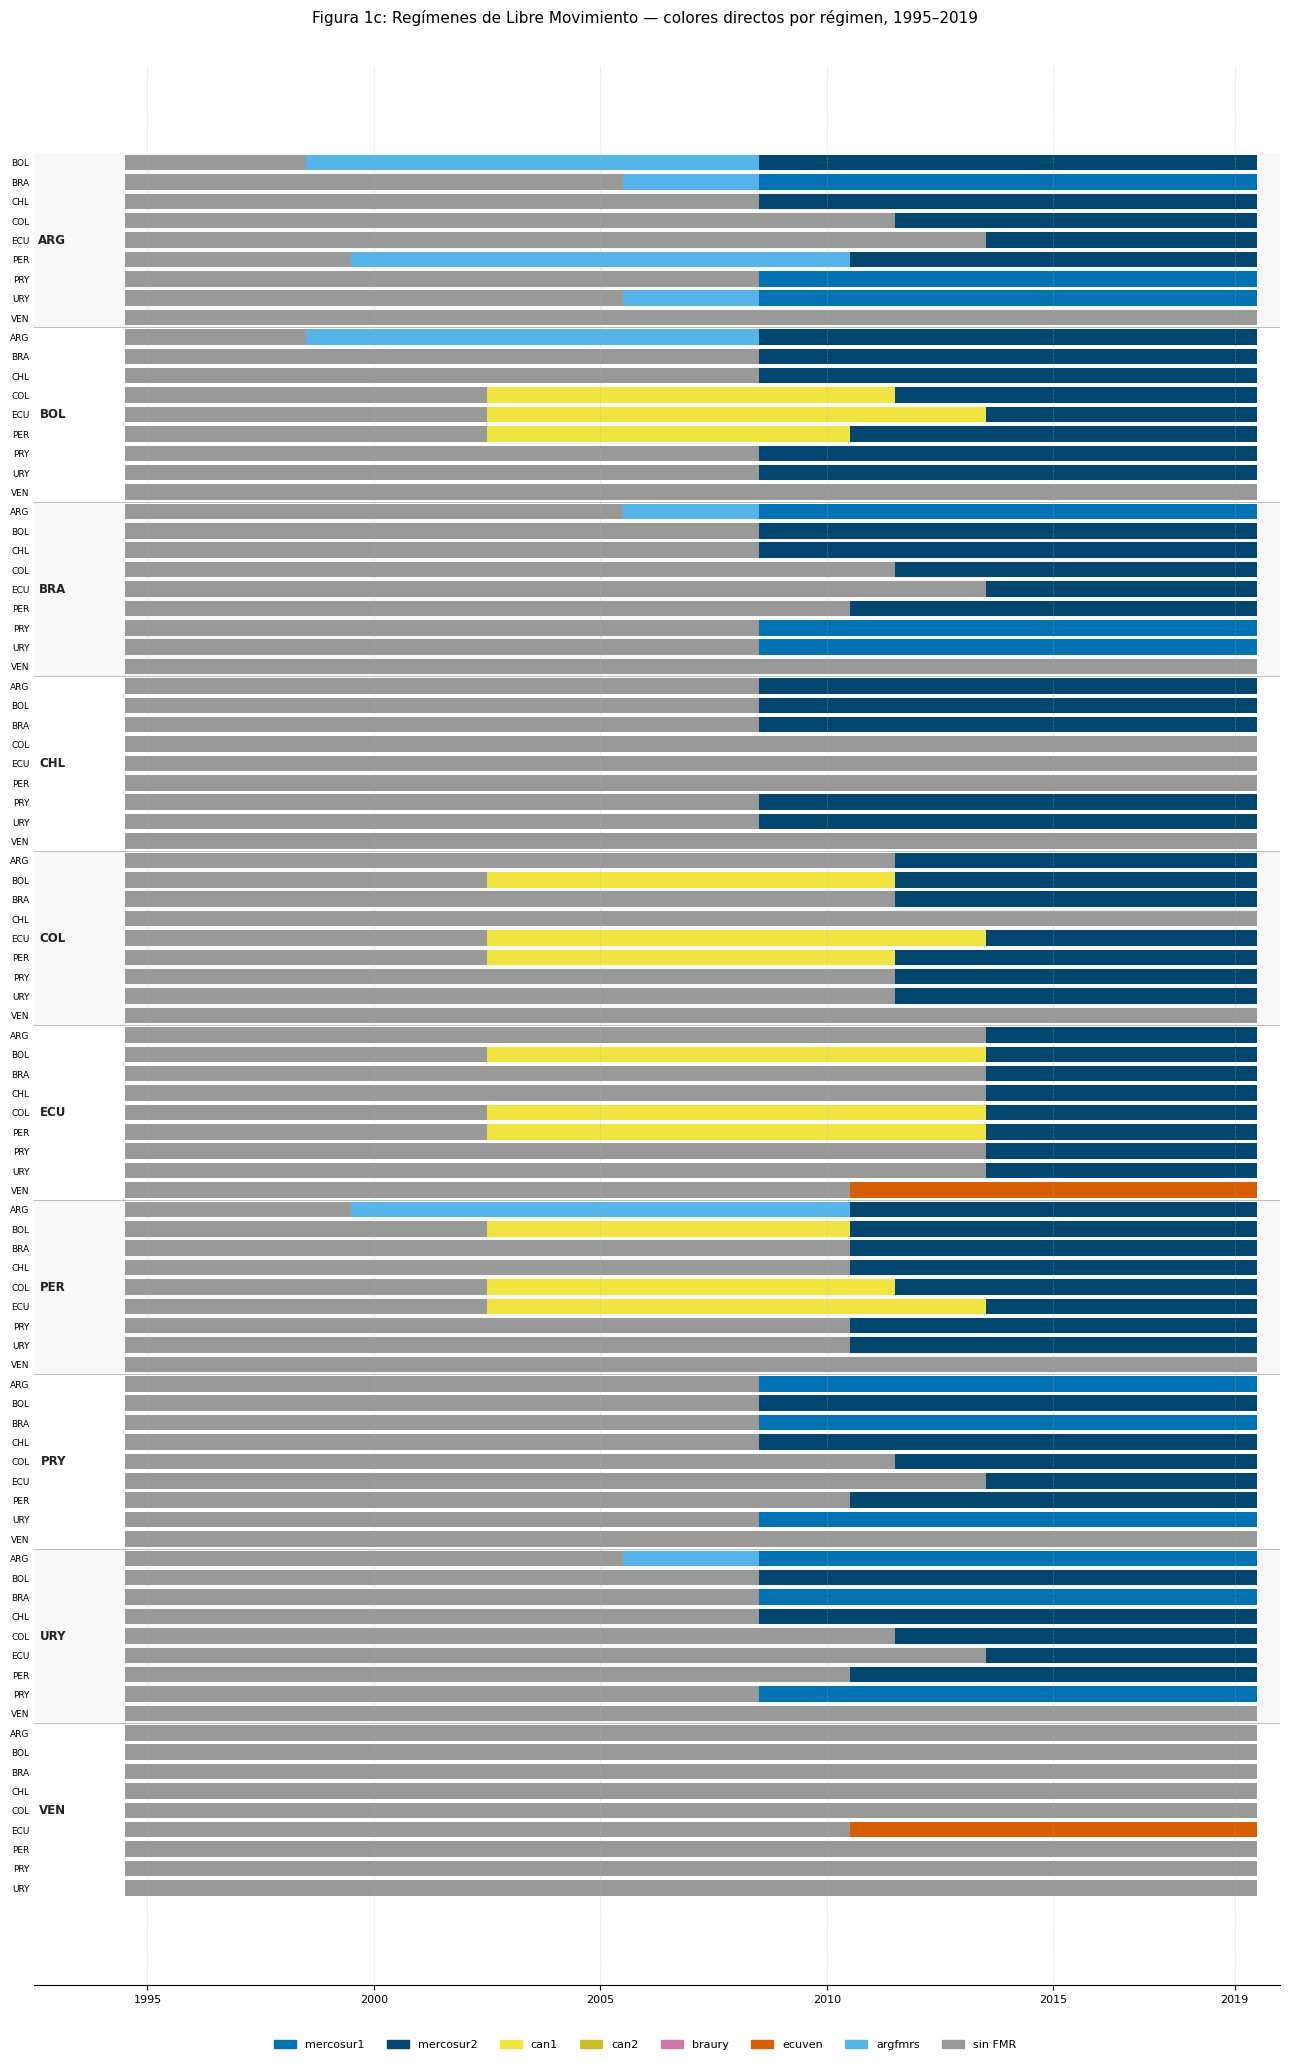

In [48]:
# Color para can2 (no en datos 1995-2019, pero incluido para completitud)
COLORS_V2 = {**COLORS, "can2": tuple(x/255 for x in (200, 190, 40))}  # amarillo oscuro

def get_fmr_color_v2(row):
    """Colores directos a los 7 FMRs. Sin colores de overlap.
    Prioridad: MERCOSUR > CAN > resto."""
    if row["mercosur1"] == 1: return COLORS_V2["mercosur1"]
    if row["mercosur2"] == 1: return COLORS_V2["mercosur2"]
    if row["can1"]      == 1: return COLORS_V2["can1"]
    if row["can2"]      == 1: return COLORS_V2["can2"]
    if row["braury"]    == 1: return COLORS_V2["braury"]
    if row["ecuven"]    == 1: return COLORS_V2["ecuven"]
    if row["argfmrs"]   == 1: return COLORS_V2["argfmrs"]
    return COLORS_V2["no_fmr"]

# Aplicar color directamente sobre df_g (no sobre df) para evitar problemas de índice
df_g["color_v2"] = df_g.apply(get_fmr_color_v2, axis=1)

# ── Gantt agrupado por destino (mismo layout que Fig. 1) ────────────────────
fig_h = max(12, n * 0.2 + 2)  # reutiliza n, ordered_pairs, dest_group_info de Fig. 1
fig, ax = plt.subplots(figsize=(13, fig_h))

ax.barh(df_g["y_gantt"], width=1, left=df_g["year"] - 0.5,
        color=df_g["color_v2"].tolist(), linewidth=0)

bg_colors = ["#f4f4f4", "white"]
for i, dest in enumerate(destinations_sorted):
    start, end = dest_group_info[dest]
    mid = (start + end - 1) / 2
    ax.axhspan(start - 0.5, end - 0.5,
               facecolor=bg_colors[i % 2], alpha=0.6, zorder=0)
    ax.text(1993.2, mid, dest,
            fontsize=8.5, fontweight="bold", ha="right", va="center",
            color="#222222")
    if start > 0:
        ax.axhline(start - 0.5, color="#bbbbbb", linewidth=0.7, zorder=3)

ax.set_yticks(range(n))
ax.set_yticklabels([p[0] for p in ordered_pairs], fontsize=6.5)
ax.invert_yaxis()
ax.set_xticks([1995, 2000, 2005, 2010, 2015, 2019])
ax.set_xlim(1992.5, 2020)
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.4, zorder=1)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", length=0)
ax.spines[["top", "right", "left"]].set_visible(False)

legend_items = [
    mpatches.Patch(color=COLORS_V2["mercosur1"], label="mercosur1"),
    mpatches.Patch(color=COLORS_V2["mercosur2"], label="mercosur2"),
    mpatches.Patch(color=COLORS_V2["can1"],      label="can1"),
    mpatches.Patch(color=COLORS_V2["can2"],      label="can2"),
    mpatches.Patch(color=COLORS_V2["braury"],    label="braury"),
    mpatches.Patch(color=COLORS_V2["ecuven"],    label="ecuven"),
    mpatches.Patch(color=COLORS_V2["argfmrs"],   label="argfmrs"),
    mpatches.Patch(color=COLORS_V2["no_fmr"],    label="sin FMR"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=8,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(
    "Figura 1c: Regímenes de Libre Movimiento — colores directos por régimen, 1995–2019",
    fontsize=11, y=1.005
)
plt.tight_layout()
plt.savefig(OUTDIR + "Fig01c_gantt_direct_colors.png", dpi=150, bbox_inches="tight")
plt.show()

## Figura 2 — Cobertura por escenario FMR

Tres paneles con el mismo layout de corredor (agrupados por destino). En cada panel un corredor-año se colorea si `FMR_X = 1`, gris si no. Permite ver de un vistazo qué corredores agrega cada escenario respecto al anterior.

> Reutiliza `n`, `ordered_pairs`, `dest_group_info`, `destinations_sorted` y `df_g` de la Figura 1.

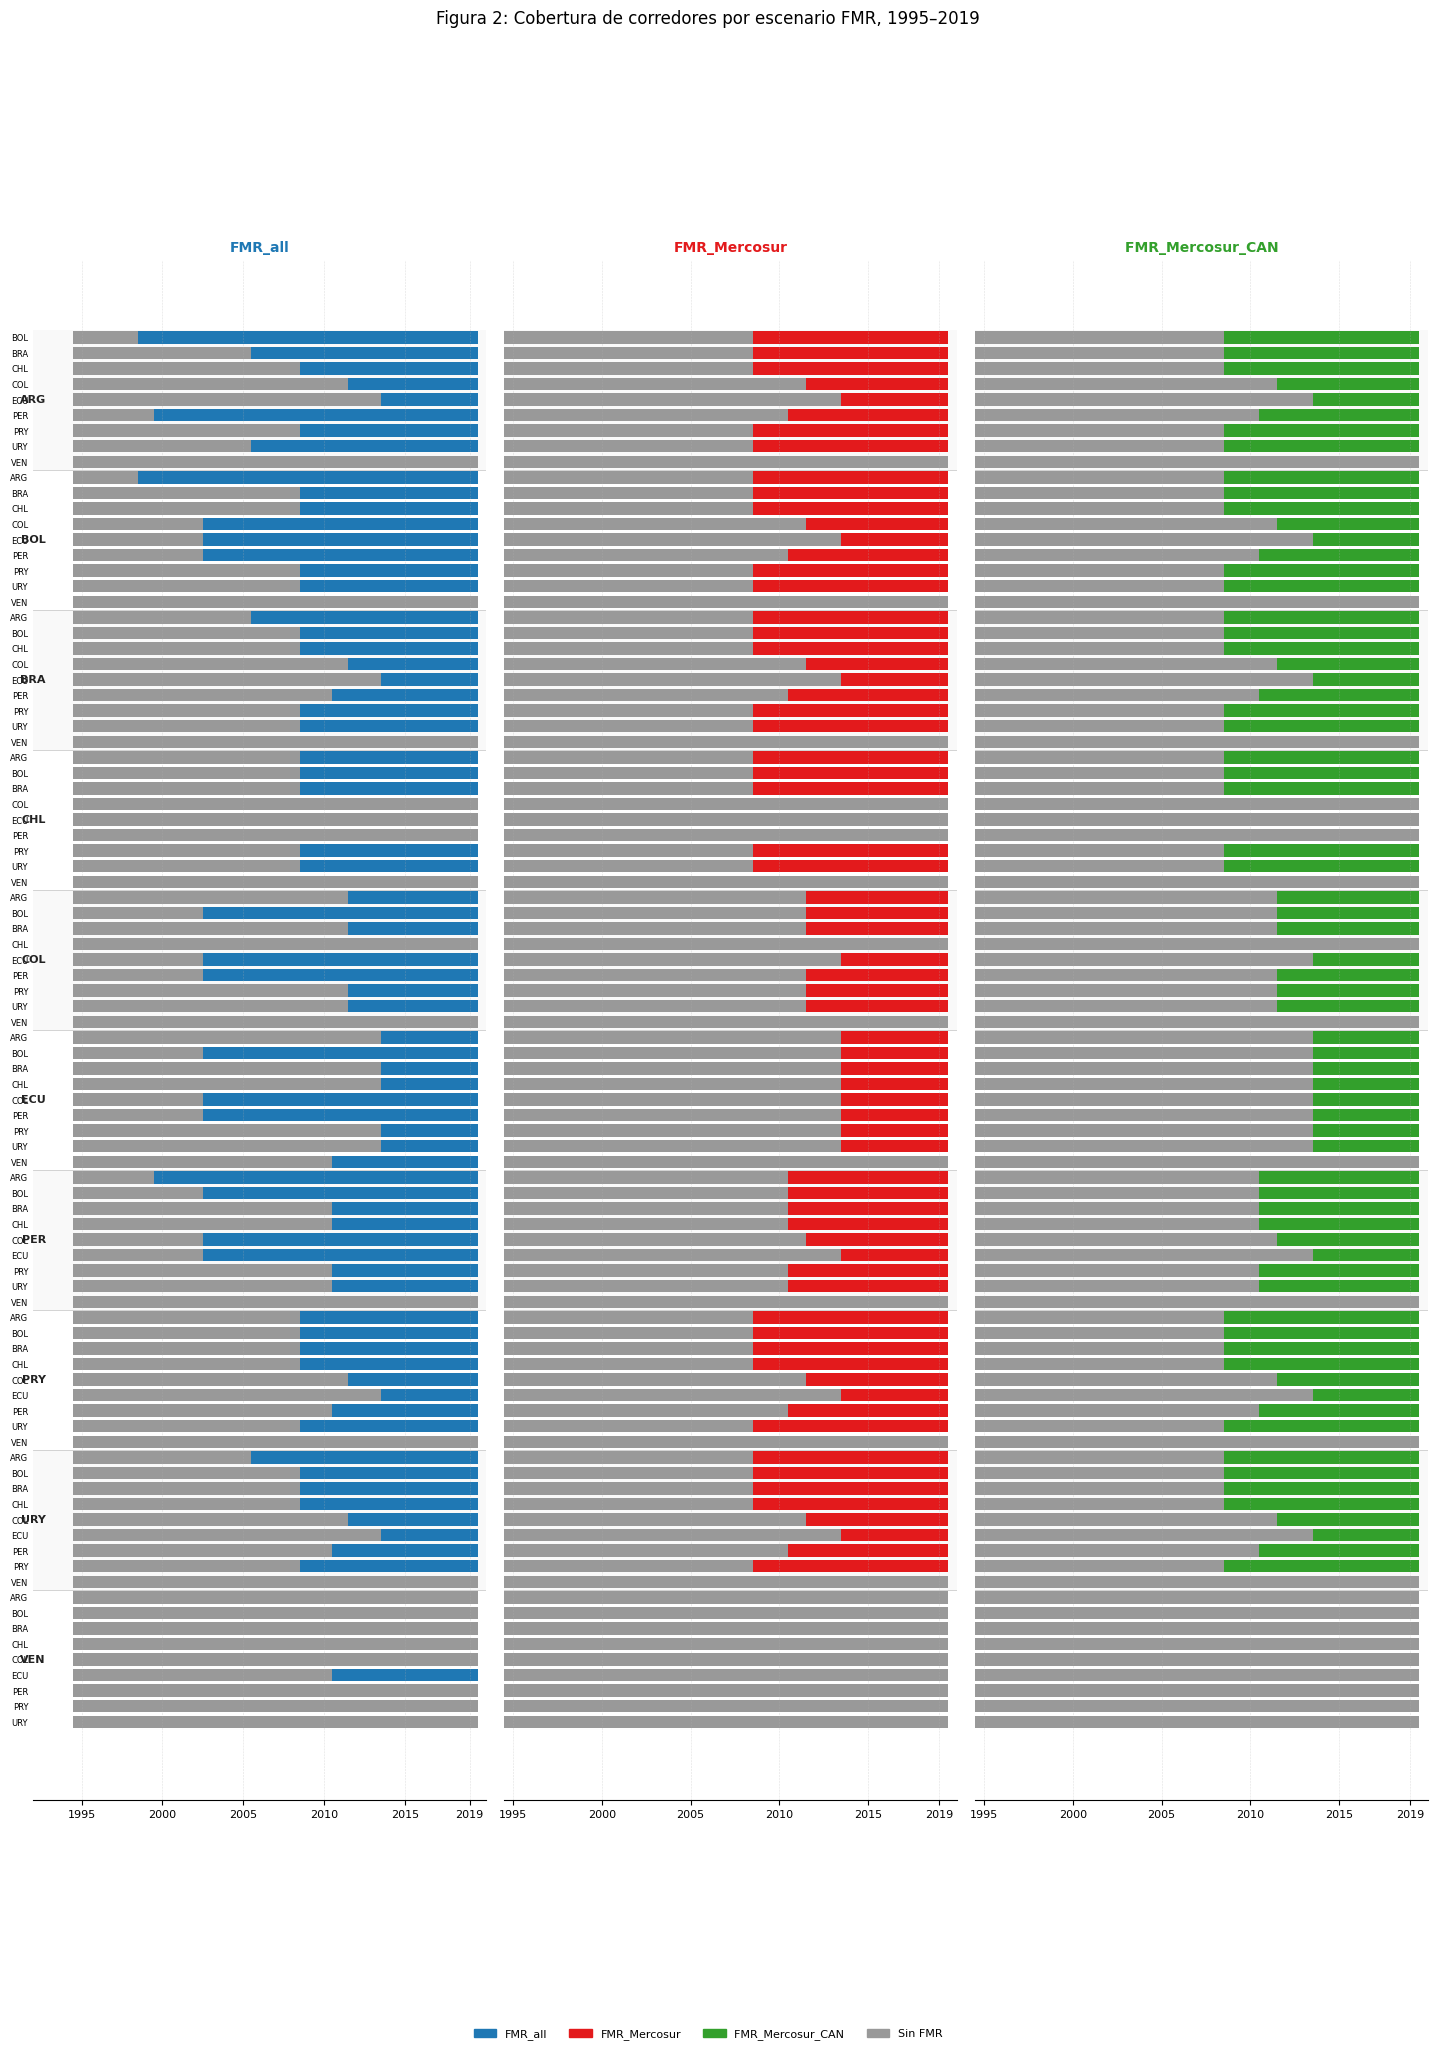

In [49]:
SCENARIOS = [
    ("FMR_all",          "FMR_all",          "#1f78b4"),
    ("FMR_Mercosur",     "FMR_Mercosur",     "#e31a1c"),
    ("FMR_Mercosur_CAN", "FMR_Mercosur​_CAN", "#33a02c"),
]
INACTIVE = COLORS["no_fmr"]

fig, axes = plt.subplots(1, 3, figsize=(18, max(12, n * 0.2 + 2)),
                          sharey=True, gridspec_kw={"wspace": 0.04})

bg_colors = ["#f4f4f4", "white"]

for col_idx, (fmr_col, title, active_color) in enumerate(SCENARIOS):
    ax = axes[col_idx]

    # Color por fila: activo o gris
    color_col = df_g[fmr_col].map({1: active_color, 0: INACTIVE})

    ax.barh(df_g["y_gantt"], width=1, left=df_g["year"] - 0.5,
            color=color_col.tolist(), linewidth=0)

    # Fondos alternados y separadores
    for i, dest in enumerate(destinations_sorted):
        start, end = dest_group_info[dest]
        ax.axhspan(start - 0.5, end - 0.5,
                   facecolor=bg_colors[i % 2], alpha=0.5, zorder=0)
        if start > 0:
            ax.axhline(start - 0.5, color="#cccccc", linewidth=0.6, zorder=3)

    # Etiquetas de destino solo en el primer panel
    if col_idx == 0:
        for dest, (start, end) in dest_group_info.items():
            mid = (start + end - 1) / 2
            ax.text(1992.8, mid, dest,
                    fontsize=8, fontweight="bold", ha="right", va="center",
                    color="#222222")
        ax.set_yticks(range(n))
        ax.set_yticklabels([p[0] for p in ordered_pairs], fontsize=6)
        ax.set_xlim(1992, 2020)
    else:
        ax.set_xlim(1994.5, 2020)
        ax.tick_params(axis="y", left=False)

    ax.set_xticks([1995, 2000, 2005, 2010, 2015, 2019])
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.4, zorder=1)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.set_title(title, fontsize=10, pad=6, color=active_color, fontweight="bold")

axes[0].invert_yaxis()

# Leyenda compartida
legend_items = [
    mpatches.Patch(color=c, label=lbl)
    for _, lbl, c in SCENARIOS
] + [mpatches.Patch(color=INACTIVE, label="Sin FMR")]
fig.legend(handles=legend_items, loc="lower center", ncol=4,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.015))
fig.suptitle(
    "Figura 2: Cobertura de corredores por escenario FMR, 1995–2019",
    fontsize=12, y=1.005
)
plt.savefig(OUTDIR + "Fig02_scenarios_gantt.png", dpi=150, bbox_inches="tight")
plt.show()